In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import copy

<Figure size 1000x600 with 0 Axes>

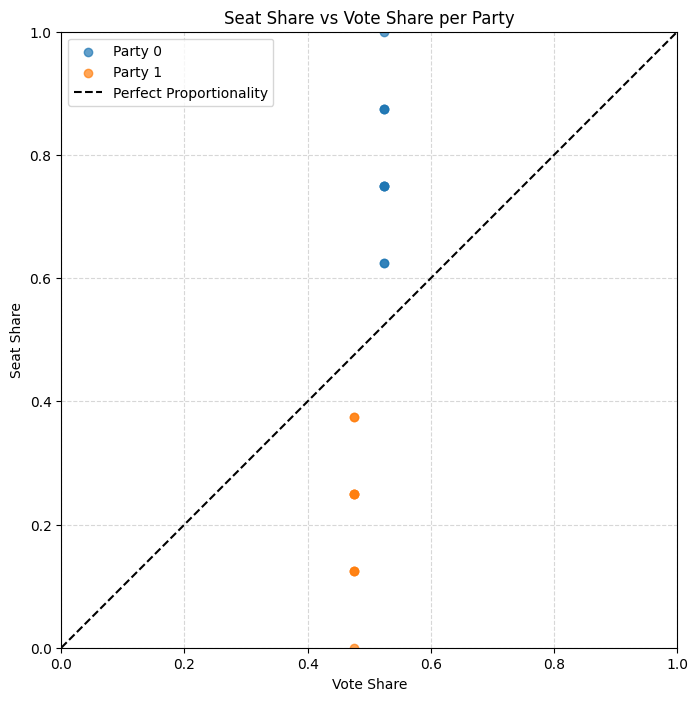

In [2]:

# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000       # Can change
NUM_PARTIES = 2         # Can change - but will reutn null efficiency gap for more than 2 parties 
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 10          # Number of redistricting simulations

NUM_CITIES = 5
CITY_INTENSITY = (5, 12)
CITY_SPREAD = (10, 30)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# ------------------------
# GENERATE POPULATION DENSITY
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ------------------------
# GENERATE VOTERS BASED ON DENSITY
# ------------------------
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# FIXED PARTY PREFERENCES
# ------------------------
voter_parties = np.random.randint(0, NUM_PARTIES, NUM_VOTERS)
voter_colors = party_colors[voter_parties]
def connected_districts(voters, num_districts, voters_per_district, k_neighbors=20):
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    # Create districts with BFS
    for d in range(num_districts):
        if not unassigned:
            break

        seed = np.random.choice(list(unassigned))
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        # Retry if district incomplete
        if count < voters_per_district:
            for i in range(N):
                if district[i] == d:
                    district[i] = -1
                    unassigned.add(i)
            return connected_districts(voters, num_districts, voters_per_district)

    # ------------------------
    # Assign leftover voters to nearest district
    # ------------------------
    leftover_indices = np.where(district == -1)[0]
    assigned_indices = np.where(district != -1)[0]

    if len(leftover_indices) > 0:
        assigned_tree = cKDTree(voters[assigned_indices])
        for i in leftover_indices:
            _, idx = assigned_tree.query(voters[i])
            nearest_assigned = assigned_indices[idx]
            district[i] = district[nearest_assigned]

    return district
# ------------------------
# COUNT VOTES
# ------------------------
def count_votes(district_labels):
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts

# ------------------------
# EFFICIENCY GAP (2-party only)
# ------------------------
def efficiency_gap(district_counts):
    if NUM_PARTIES != 2:
        return None
    wasted = {party: 0 for party in PARTY_IDS}
    total_votes = 0

    for d in district_counts:
        total = sum(d.values())
        total_votes += total
        winner = max(d, key=d.get)
        for party in PARTY_IDS:
            if party == winner:
                wasted[party] += d[party] - total / 2
            else:
                wasted[party] += d[party]

    return (wasted[PARTY_IDS[0]] - wasted[PARTY_IDS[1]]) / total_votes

# ------------------------
# FORWARD & BACKWARD VOTE SHIFTS 
# ------------------------
def simulate_vote_shifts_forward(district_counts, target_party):
    counts = copy.deepcopy(district_counts)
    competitors = [p for p in PARTY_IDS if p != target_party]

    def district_winner(d): return max(d, key=d.get)
    def count_wins(): return sum(1 for d in counts if district_winner(d) == target_party)
    def vote_share(): return sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)

    current_wins = count_wins()
    history = []
    initial_wins = current_wins
    initial_share = vote_share()

    while True:
        any_shift = False
        for d in counts:
            moved = 0
            for p in competitors:
                if d[p] > 0:
                    d[p] -= 1
                    moved += 1
            d[target_party] += moved
            if moved > 0:
                any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            history.append({"districts_won": new_wins, "vote_share": vote_share()})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return {"history": history, "initial_wins": initial_wins, "initial_vote_share": initial_share}

def simulate_vote_shifts_backward(district_counts, target_party):
    counts = copy.deepcopy(district_counts)
    competitors = [p for p in PARTY_IDS if p != target_party]

    def district_winner(d): return max(d, key=d.get)
    def count_wins(): return sum(1 for d in counts if district_winner(d) == target_party)
    def vote_share(): return sum(d[target_party] for d in counts) / sum(sum(d.values()) for d in counts)

    current_wins = count_wins()
    history = []
    initial_wins = current_wins
    initial_share = vote_share()

    while True:
        any_shift = False
        for d in counts:
            if d[target_party] > 0:
                d[target_party] -= 1
                comp = max(competitors, key=lambda p: d[p])
                d[comp] += 1
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            history.append({"districts_won": new_wins, "vote_share": vote_share()})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return {"history": history, "initial_wins": initial_wins, "initial_vote_share": initial_share}

# ------------------------
# RUN SIMULATIONS
# ------------------------
all_efficiency_gaps = []
all_seat_counts = []
all_vote_shares = []       # Party 0 only, optional
all_seat_shares = []       # Party 0 only, optional
all_pr_vote_shares = []    # dict of all parties
all_pr_seat_shares = []    # dict of all parties

plt.figure(figsize=(10,6))

for run in range(NUM_RUNS):
    district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)
    district_counts = count_votes(district_labels)

    # Efficiency gap
    gap = efficiency_gap(district_counts)
    all_efficiency_gaps.append(gap)

    # ------------------------
    # Proportional Representation (all parties)
    # ------------------------
    pr_vote_share = {party: 0 for party in PARTY_IDS}
    pr_seat_share = {party: 0 for party in PARTY_IDS}

    for d in district_counts:
        for party in PARTY_IDS:
            pr_vote_share[party] += d[party]

    # Normalize vote share
    total_votes = sum(pr_vote_share.values())
    for party in PARTY_IDS:
        pr_vote_share[party] /= total_votes

    # Seat share
    for d in district_counts:
        winner = max(d, key=d.get)
        pr_seat_share[winner] += 1
    for party in PARTY_IDS:
        pr_seat_share[party] /= NUM_DISTRICTS

    all_pr_vote_shares.append(pr_vote_share)
    all_pr_seat_shares.append(pr_seat_share)

# ------------------------
# SCATTER PLOT: Vote Share vs Seat Share
# ------------------------
plt.figure(figsize=(8,8))
for party in PARTY_IDS:
    vote_shares = [run[party] for run in all_pr_vote_shares]
    seat_shares = [run[party] for run in all_pr_seat_shares]
    plt.scatter(vote_shares, seat_shares, alpha=0.7, label=party)

plt.plot([0,1],[0,1], linestyle='--', color='black', label='Perfect Proportionality')
plt.xlabel("Vote Share")
plt.ylabel("Seat Share")
plt.title("Seat Share vs Vote Share per Party")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlim(0,1)
plt.ylim(0,1)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()




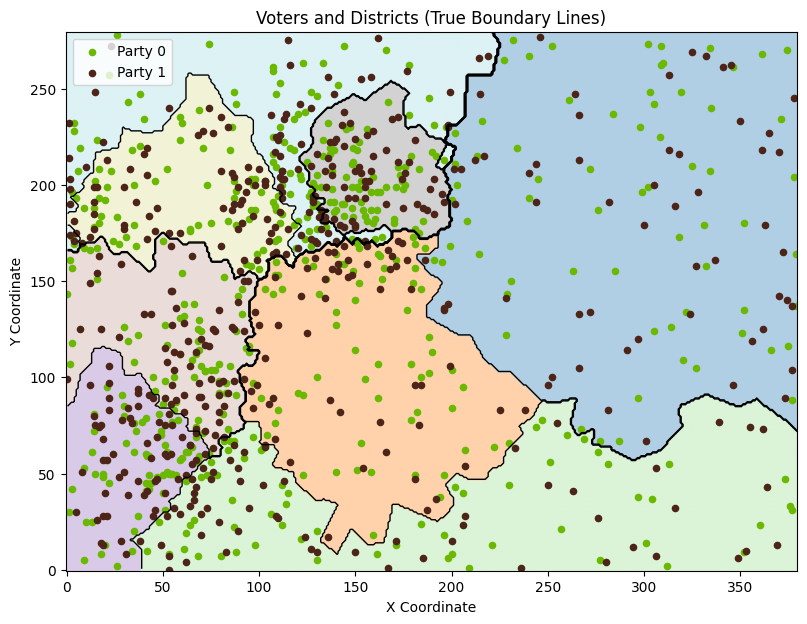

In [3]:
# ------------------------
# VISUALIZE ONE RUN (NO OVERLAP)
# ------------------------

district_labels = connected_districts(voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT)

# Build KD-tree for fast nearest lookup
tree = cKDTree(voters)

# Create grid of every pixel
xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
grid_points = np.column_stack((xx.ravel(), yy.ravel()))

# Assign each pixel to nearest voter
_, nearest_voter = tree.query(grid_points)
pixel_districts = district_labels[nearest_voter]
pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

plt.figure(figsize=(10,7))

# Lightly color districts
plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)

# Draw district boundaries
plt.contour(
    pixel_map,
    levels=np.arange(NUM_DISTRICTS)+0.5,
    colors='black',
    linewidths=1,
    origin='lower'
)

# Plot voters on top
for i, party in enumerate(PARTY_IDS):
    mask = voter_parties == i
    plt.scatter(
        voters[mask,0],
        voters[mask,1],
        color=PARTY_COLORS[party],
        label=party,
        s=20
    )

plt.title("Voters and Districts (True Boundary Lines)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend()
plt.show()



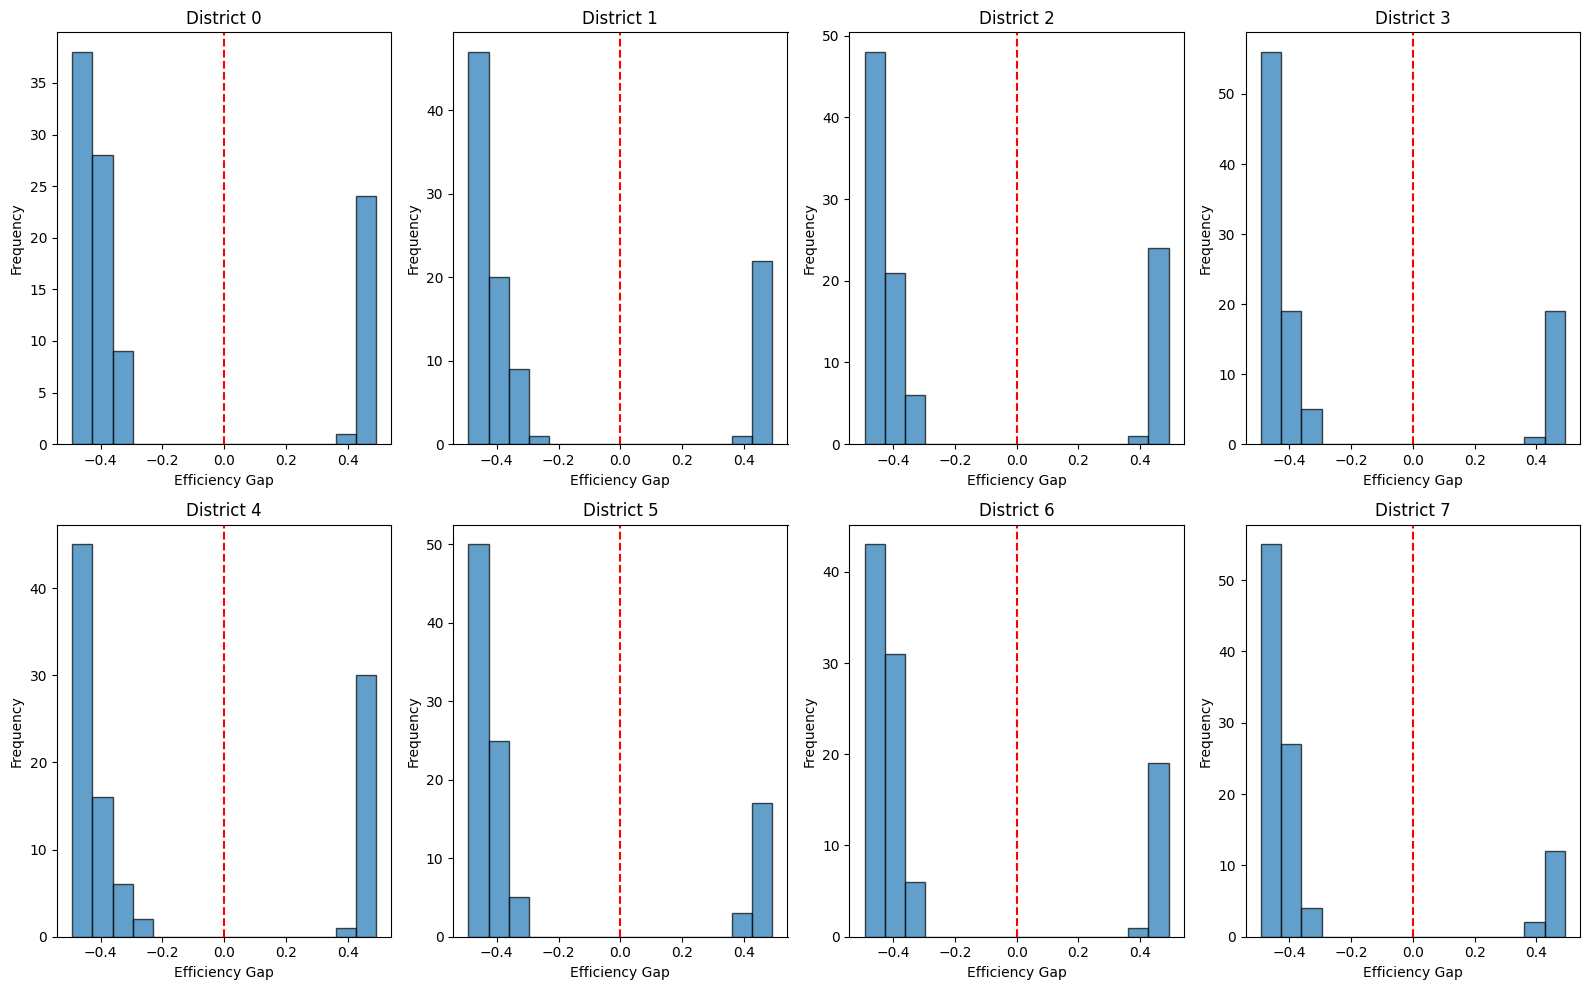


----- DISTRICT EFFICIENCY GAP SUMMARY -----
District 0: Mean = -0.1988, Std = 0.3885
District 1: Mean = -0.2249, Std = 0.3778
District 2: Mean = -0.2046, Std = 0.3886
District 3: Mean = -0.2547, Std = 0.3645
District 4: Mean = -0.1506, Std = 0.4202
District 5: Mean = -0.2507, Std = 0.3608
District 6: Mean = -0.2432, Std = 0.3586
District 7: Mean = -0.3085, Std = 0.3098


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import copy
from scipy.spatial import cKDTree

# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 1000
NUM_PARTIES = 2
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 100

NUM_CITIES = 5
CITY_INTENSITY = (5, 12)
CITY_SPREAD = (10, 30)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

# ------------------------
# GENERATE POPULATION DENSITY
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))

for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

# ------------------------
# GENERATE VOTERS BASED ON DENSITY
# ------------------------
flat_density = density.ravel()
flat_density /= flat_density.sum()
indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# FIXED PARTY PREFERENCES
# ------------------------
voter_parties = np.random.randint(0, NUM_PARTIES, NUM_VOTERS)

# ------------------------
# CONNECTED DISTRICTS
# ------------------------
def connected_districts(voters, num_districts, voters_per_district, k_neighbors=20):
    N = len(voters)
    district = -np.ones(N, dtype=int)
    tree = cKDTree(voters)
    unassigned = set(range(N))

    for d in range(num_districts):
        if not unassigned:
            break

        seed = np.random.choice(list(unassigned))
        district[seed] = d
        unassigned.remove(seed)
        queue = [seed]
        count = 1

        while queue and count < voters_per_district:
            current = queue.pop(0)
            _, neighbors = tree.query(voters[current], k=k_neighbors)

            for n in neighbors:
                if n in unassigned:
                    district[n] = d
                    unassigned.remove(n)
                    queue.append(n)
                    count += 1
                    if count >= voters_per_district:
                        break

        if count < voters_per_district:
            return connected_districts(voters, num_districts, voters_per_district)

    leftover = np.where(district == -1)[0]
    assigned = np.where(district != -1)[0]

    if len(leftover) > 0:
        assigned_tree = cKDTree(voters[assigned])
        for i in leftover:
            _, idx = assigned_tree.query(voters[i])
            district[i] = district[assigned[idx]]

    return district

# ------------------------
# COUNT VOTES
# ------------------------
def count_votes(district_labels):
    district_counts = []
    for d in range(NUM_DISTRICTS):
        mask = district_labels == d
        counts = {party: 0 for party in PARTY_IDS}
        for i in np.where(mask)[0]:
            counts[PARTY_IDS[voter_parties[i]]] += 1
        district_counts.append(counts)
    return district_counts

# ------------------------
# DISTRICT-LEVEL EFFICIENCY GAP
# ------------------------
def district_efficiency_gap(district_count):
    if NUM_PARTIES != 2:
        return None
    
    total = sum(district_count.values())
    winner = max(district_count, key=district_count.get)

    wasted = {}
    for party in PARTY_IDS:
        if party == winner:
            wasted[party] = district_count[party] - total / 2
        else:
            wasted[party] = district_count[party]

    return (wasted[PARTY_IDS[0]] - wasted[PARTY_IDS[1]]) / total

# ------------------------
# RUN SIMULATIONS
# ------------------------
district_gaps_across_runs = [[] for _ in range(NUM_DISTRICTS)]

for run in range(NUM_RUNS):
    district_labels = connected_districts(
        voters, NUM_DISTRICTS, VOTERS_PER_DISTRICT
    )
    district_counts = count_votes(district_labels)

    for d in range(NUM_DISTRICTS):
        gap = district_efficiency_gap(district_counts[d])
        district_gaps_across_runs[d].append(gap)

# ------------------------
# PLOT: ONE HISTOGRAM PER DISTRICT
# ------------------------
plt.figure(figsize=(16, 10))

rows = 2
cols = 4

for d in range(NUM_DISTRICTS):
    plt.subplot(rows, cols, d + 1)
    plt.hist(
        district_gaps_across_runs[d],
        bins=15,
        edgecolor='black',
        alpha=0.7
    )
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"District {d}")
    plt.xlabel("Efficiency Gap")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# ------------------------
# SUMMARY STATISTICS
# ------------------------
print("\n----- DISTRICT EFFICIENCY GAP SUMMARY -----")
for d in range(NUM_DISTRICTS):
    mean_gap = np.mean(district_gaps_across_runs[d])
    std_gap = np.std(district_gaps_across_runs[d])
    print(f"District {d}: Mean = {mean_gap:.4f}, Std = {std_gap:.4f}")